# Кластерный анализ механико-гемодинамической адаптации к нагрузке

## Цель этапа

На данном этапе выполняется кластерный анализ внутри группы переменных, описывающих механико-гемодинамическую адаптацию левого желудочка к нагрузке.

В кластеризацию включаются следующие переменные:

- `dsws` — прирост систолического артериального давления на нагрузке;
- `echo_lv_sws_delta_g_cm2` — прирост систолического напряжения стенки ЛЖ;
- `echo_lv_sphericity_index_end_systolic_ratio` — индекс сферичности ЛЖ в конце систолы;
- `echo_lv_sphericity_index_end_diastolic_ratio` — индекс сферичности ЛЖ в конце диастолы.

## Логика этапа

Сначала мы не сравниваем хорды и не строим сложные модели, а пытаемся выделить скрытые фенотипы адаптации ЛЖ к нагрузке на основе трёх физиологических слоёв:

1. гемодинамическая реакция на нагрузку;
2. прирост напряжения стенки ЛЖ;
3. изменение / особенности геометрии ЛЖ.

## Главная идея

`dsws` отражает прирост давления, а `echo_lv_sws_delta_g_cm2` отражает уже расчётную механическую нагрузку на стенку ЛЖ.

Поэтому эти переменные не дублируют друг друга:

```text
dsws = гемодинамическая нагрузка давлением
echo_lv_sws_delta_g_cm2 = механическая нагрузка на стенку ЛЖ

In [7]:
# ============================================================
# 0. Импорты и глобальные настройки
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Настройки pandas
# ------------------------------------------------------------

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

# ------------------------------------------------------------
# Пути
# ------------------------------------------------------------

DATA_PATH = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx")

OUTPUT_DIR = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

# ------------------------------------------------------------
# Академический стиль графиков
# ------------------------------------------------------------

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"
plt.rcParams["text.color"] = "black"

plt.rcParams["grid.color"] = "#D9D9D9"
plt.rcParams["grid.linestyle"] = "-"
plt.rcParams["grid.linewidth"] = 0.8

def apply_publication_style(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.tick_params(axis="both", colors="black", labelsize=10)
    ax.grid(True, axis="y", alpha=0.5)
    return ax

DATA_PATH: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx
OUTPUT_DIR: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load


In [8]:
# ============================================================
# 1. Загрузка данных и выбор переменных кластеризации
# ============================================================

df = pd.read_excel(DATA_PATH)

print(f"Размер исходного датасета: {df.shape[0]} строк × {df.shape[1]} колонок")

cluster_vars = [
    "dsws",
    "echo_lv_sws_delta_g_cm2",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_sphericity_index_end_diastolic_ratio",
]

missing_vars = [col for col in cluster_vars if col not in df.columns]
existing_vars = [col for col in cluster_vars if col in df.columns]

print("\nНайдены переменные:")
for col in existing_vars:
    print("  -", col)

if missing_vars:
    print("\nНЕ найдены переменные:")
    for col in missing_vars:
        print("  -", col)
else:
    print("\nВсе переменные для текущего этапа найдены.")

cluster_df = df[existing_vars].copy()

cluster_df.head()

Размер исходного датасета: 153 строк × 222 колонок

Найдены переменные:
  - dsws
  - echo_lv_sws_delta_g_cm2
  - echo_lv_sphericity_index_end_systolic_ratio
  - echo_lv_sphericity_index_end_diastolic_ratio

Все переменные для текущего этапа найдены.


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
0,37.0,35.371669,0.463,0.343
1,NaN,NaN,NaN,NaN
2,42.0,38.579679,0.505,0.602
3,46.0,40.536860,0.514,0.400
4,21.0,26.281070,0.576,0.530


In [9]:
# ============================================================
# 2. Первичный аудит: типы, пропуски, размер рабочей выборки
# ============================================================

audit_table = pd.DataFrame({
    "variable": cluster_df.columns,
    "dtype": cluster_df.dtypes.astype(str).values,
    "n_missing": cluster_df.isna().sum().values,
    "pct_missing": (cluster_df.isna().mean() * 100).round(2).values,
    "n_unique": cluster_df.nunique(dropna=True).values,
})

display(audit_table)

complete_cases_mask = cluster_df.notna().all(axis=1)
cluster_df_complete = cluster_df.loc[complete_cases_mask].copy()

print(f"\nПолная выборка: {cluster_df.shape[0]} наблюдений")
print(f"Полные случаи для кластеризации: {cluster_df_complete.shape[0]} наблюдений")
print(f"Исключено из-за пропусков: {cluster_df.shape[0] - cluster_df_complete.shape[0]}")

,variable,dtype,n_missing,pct_missing,n_unique
0,dsws,float64,87,56.86,30
1,echo_lv_sws_delta_g_cm2,float64,120,78.43,33
2,echo_lv_sphericity_index_end_systolic_ratio,float64,53,34.64,74
3,echo_lv_sphericity_index_end_diastolic_ratio,float64,53,34.64,72



Полная выборка: 153 наблюдений
Полные случаи для кластеризации: 27 наблюдений
Исключено из-за пропусков: 126


In [10]:
# ============================================================
# 3. Описательная статистика по переменным кластеризации
# ============================================================

desc = cluster_df_complete.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc["missing_in_original_n"] = cluster_df.isna().sum()
desc["missing_in_original_pct"] = (cluster_df.isna().mean() * 100).round(2)

display(desc)

desc.to_excel(TABLES_DIR / "descriptive_statistics_cluster_variables.xlsx")
print("Таблица сохранена:", TABLES_DIR / "descriptive_statistics_cluster_variables.xlsx")

,count,mean,std,min,5%,25%,50%,75%,95%,max,missing_in_original_n,missing_in_original_pct
dsws,27.0,23.148148,11.934770,-3.000000,5.300000,16.000000,21.000000,31.500000,41.400000,46.000000,87,56.86
echo_lv_sws_delta_g_cm2,27.0,26.132759,24.528571,3.042909,4.877478,13.480682,21.944419,33.310835,40.339329,135.312821,120,78.43
echo_lv_sphericity_index_end_systolic_ratio,27.0,0.433481,0.062278,0.349000,0.353600,0.378000,0.438000,0.478000,0.526600,0.576000,53,34.64
echo_lv_sphericity_index_end_diastolic_ratio,27.0,0.486037,0.062021,0.343000,0.379000,0.448500,0.472000,0.532500,0.572800,0.602000,53,34.64


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\tables\descriptive_statistics_cluster_variables.xlsx


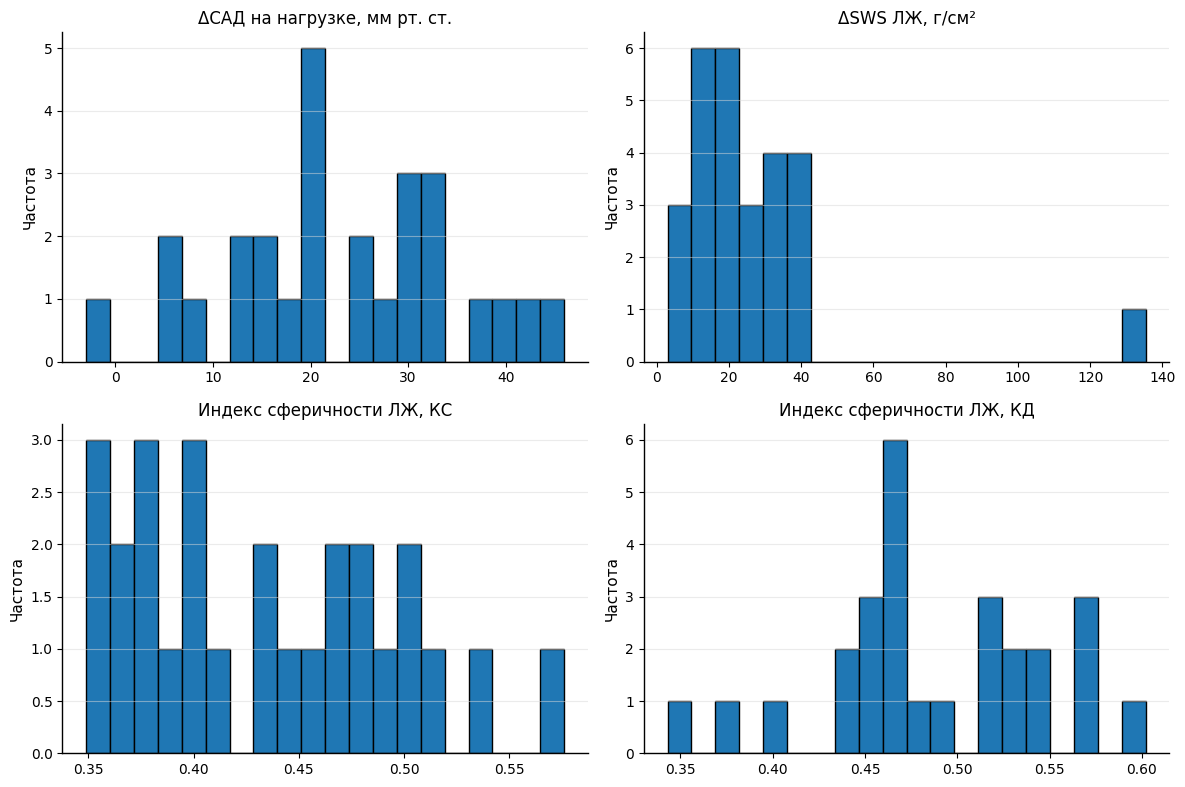

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\01_distributions_cluster_variables.png


In [11]:
# ============================================================
# 4. Распределения переменных
# ============================================================

pretty_names = {
    "dsws": "ΔСАД на нагрузке, мм рт. ст.",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
    
for ax, col in zip(axes, cluster_df_complete.columns):
    values = cluster_df_complete[col].dropna()

    ax.hist(values, bins=20, edgecolor="black", linewidth=1.0)
    ax.set_title(pretty_names.get(col, col))
    ax.set_xlabel("")
    ax.set_ylabel("Частота")
    apply_publication_style(ax)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_distributions_cluster_variables.png", dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", FIGURES_DIR / "01_distributions_cluster_variables.png")

In [12]:
# ============================================================
# 3. Описательная статистика по переменным кластеризации
# ============================================================

desc = cluster_df_complete.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
desc["missing_in_original_n"] = cluster_df.isna().sum()
desc["missing_in_original_pct"] = (cluster_df.isna().mean() * 100).round(2)

display(desc)

desc.to_excel(TABLES_DIR / "descriptive_statistics_cluster_variables.xlsx")
print("Таблица сохранена:", TABLES_DIR / "descriptive_statistics_cluster_variables.xlsx")

,count,mean,std,min,5%,25%,50%,75%,95%,max,missing_in_original_n,missing_in_original_pct
dsws,27.0,23.148148,11.934770,-3.000000,5.300000,16.000000,21.000000,31.500000,41.400000,46.000000,87,56.86
echo_lv_sws_delta_g_cm2,27.0,26.132759,24.528571,3.042909,4.877478,13.480682,21.944419,33.310835,40.339329,135.312821,120,78.43
echo_lv_sphericity_index_end_systolic_ratio,27.0,0.433481,0.062278,0.349000,0.353600,0.378000,0.438000,0.478000,0.526600,0.576000,53,34.64
echo_lv_sphericity_index_end_diastolic_ratio,27.0,0.486037,0.062021,0.343000,0.379000,0.448500,0.472000,0.532500,0.572800,0.602000,53,34.64


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\tables\descriptive_statistics_cluster_variables.xlsx


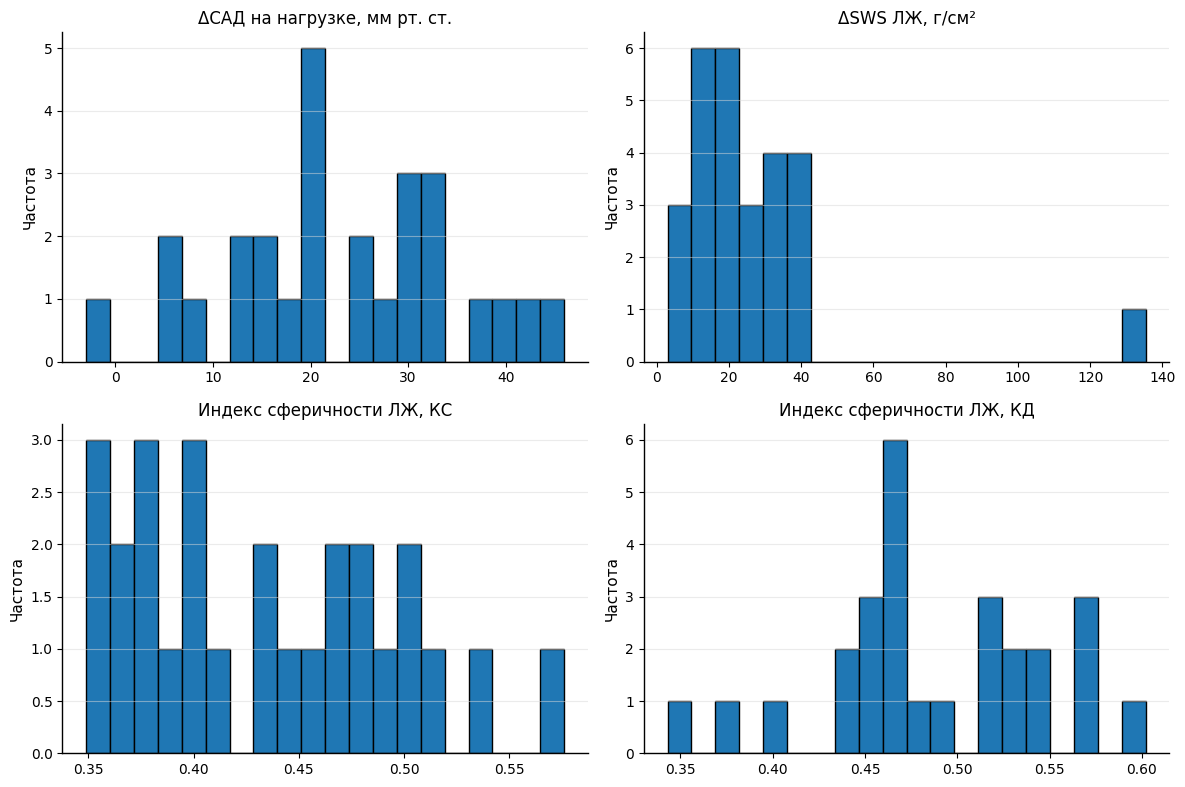

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\01_distributions_cluster_variables.png


In [13]:
# ============================================================
# 4. Распределения переменных
# ============================================================

pretty_names = {
    "dsws": "ΔСАД на нагрузке, мм рт. ст.",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",
}


fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, cluster_df_complete.columns):
    values = cluster_df_complete[col].dropna()

    ax.hist(values, bins=20, edgecolor="black", linewidth=1.0)
    ax.set_title(pretty_names.get(col, col))
    ax.set_xlabel("")
    ax.set_ylabel("Частота")
    apply_publication_style(ax)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_distributions_cluster_variables.png", dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", FIGURES_DIR / "01_distributions_cluster_variables.png")

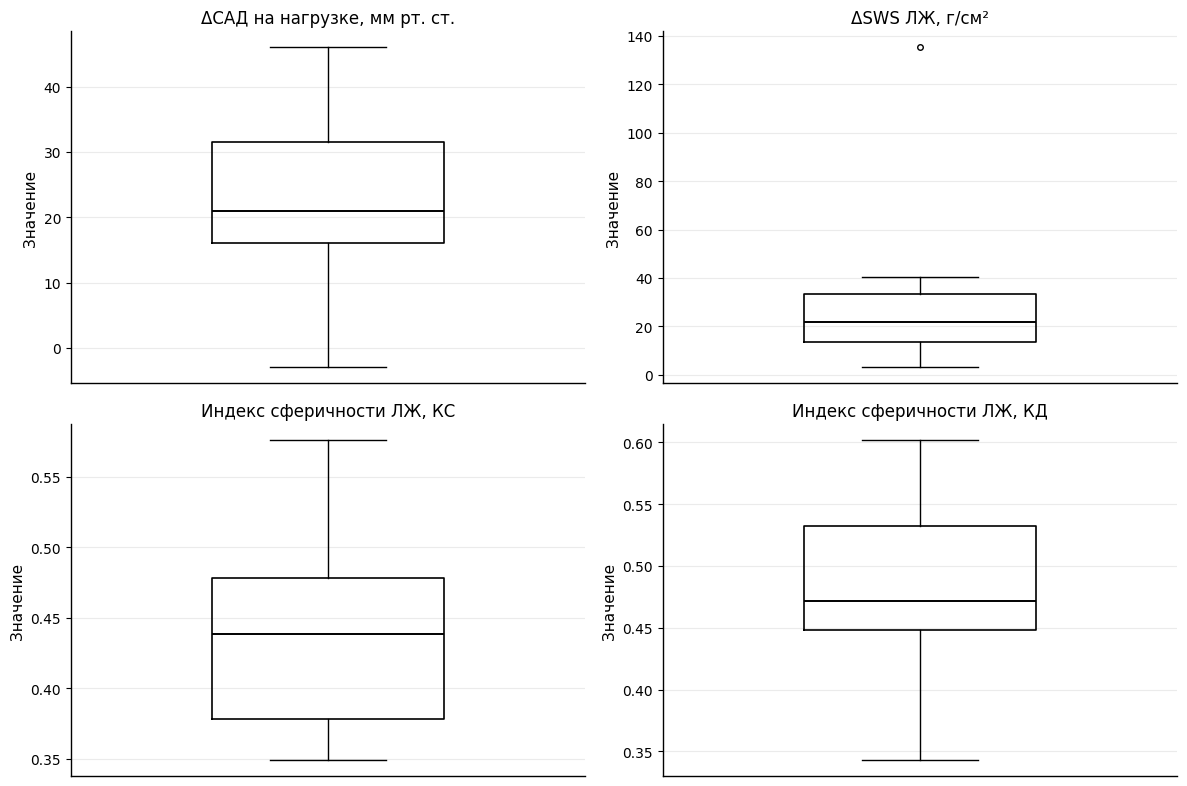

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\02_boxplots_cluster_variables.png


In [14]:
# ============================================================
# 5. Boxplot-проверка на выбросы
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, cluster_df_complete.columns):
    values = cluster_df_complete[col].dropna()

    ax.boxplot(
        values,
        vert=True,
        widths=0.45,
        patch_artist=False,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=4)
    )
    ax.set_title(pretty_names.get(col, col))
    ax.set_xticks([])
    ax.set_ylabel("Значение")
    apply_publication_style(ax)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_boxplots_cluster_variables.png", dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", FIGURES_DIR / "02_boxplots_cluster_variables.png")

,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
dsws,1.000000,0.380181,0.258529,0.045914
echo_lv_sws_delta_g_cm2,0.380181,1.000000,0.236336,-0.116389
echo_lv_sphericity_index_end_systolic_ratio,0.258529,0.236336,1.000000,0.325592
echo_lv_sphericity_index_end_diastolic_ratio,0.045914,-0.116389,0.325592,1.000000


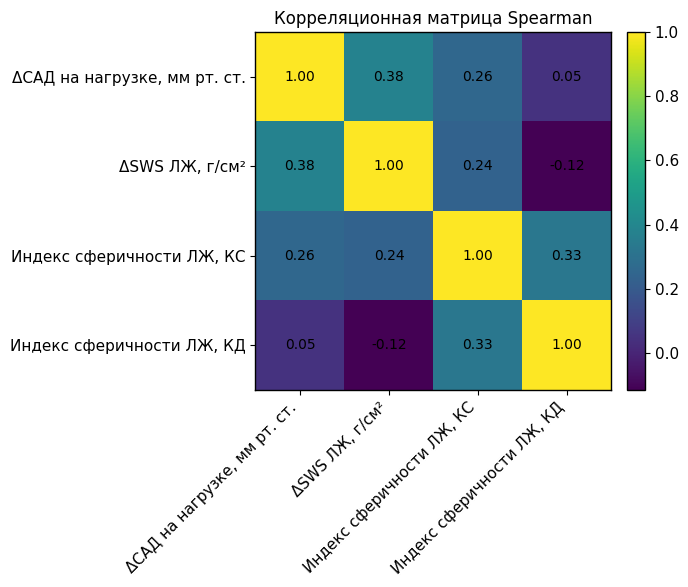

Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\tables\spearman_correlation_matrix_cluster_variables.xlsx


In [15]:
# ============================================================
# 6. Корреляционная матрица (Spearman)
# ============================================================

corr = cluster_df_complete.corr(method="spearman")

display(corr)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(corr.values, interpolation="nearest", aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))

ax.set_xticklabels([pretty_names.get(c, c) for c in corr.columns], rotation=45, ha="right")
ax.set_yticklabels([pretty_names.get(c, c) for c in corr.index])

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=10)

ax.set_title("Корреляционная матрица Spearman")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_spearman_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

corr.to_excel(TABLES_DIR / "spearman_correlation_matrix_cluster_variables.xlsx")
print("Таблица сохранена:", TABLES_DIR / "spearman_correlation_matrix_cluster_variables.xlsx")

In [18]:
# ============================================================
# 7. Z-стандартизация переменных для кластеризации
# ============================================================

from sklearn.preprocessing import StandardScaler

# Берём только полные случаи по переменным кластеризации
X_raw = cluster_df_complete[cluster_vars].copy()

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_raw)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=cluster_vars,
    index=X_raw.index
)

print("Размер матрицы для кластеризации:", X_scaled.shape)

print("\nСредние после z-стандартизации:")
display(X_scaled.mean().round(6))

print("\nСтандартные отклонения после z-стандартизации:")
display(X_scaled.std(ddof=0).round(6))

display(X_scaled.head())

Размер матрицы для кластеризации: (27, 4)

Средние после z-стандартизации:


dsws                                           -0.0
echo_lv_sws_delta_g_cm2                        -0.0
echo_lv_sphericity_index_end_systolic_ratio    -0.0
echo_lv_sphericity_index_end_diastolic_ratio   -0.0
dtype: float64


Стандартные отклонения после z-стандартизации:


dsws                                            1.0
echo_lv_sws_delta_g_cm2                         1.0
echo_lv_sphericity_index_end_systolic_ratio     1.0
echo_lv_sphericity_index_end_diastolic_ratio    1.0
dtype: float64

,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
0,1.182739,0.383834,0.483013,-2.350186
2,1.609664,0.517112,1.170260,1.905342
3,1.951203,0.598424,1.317527,-1.413641
4,-0.183419,0.006162,2.332036,0.722338
5,-0.183419,-0.167026,-1.120565,-0.394943


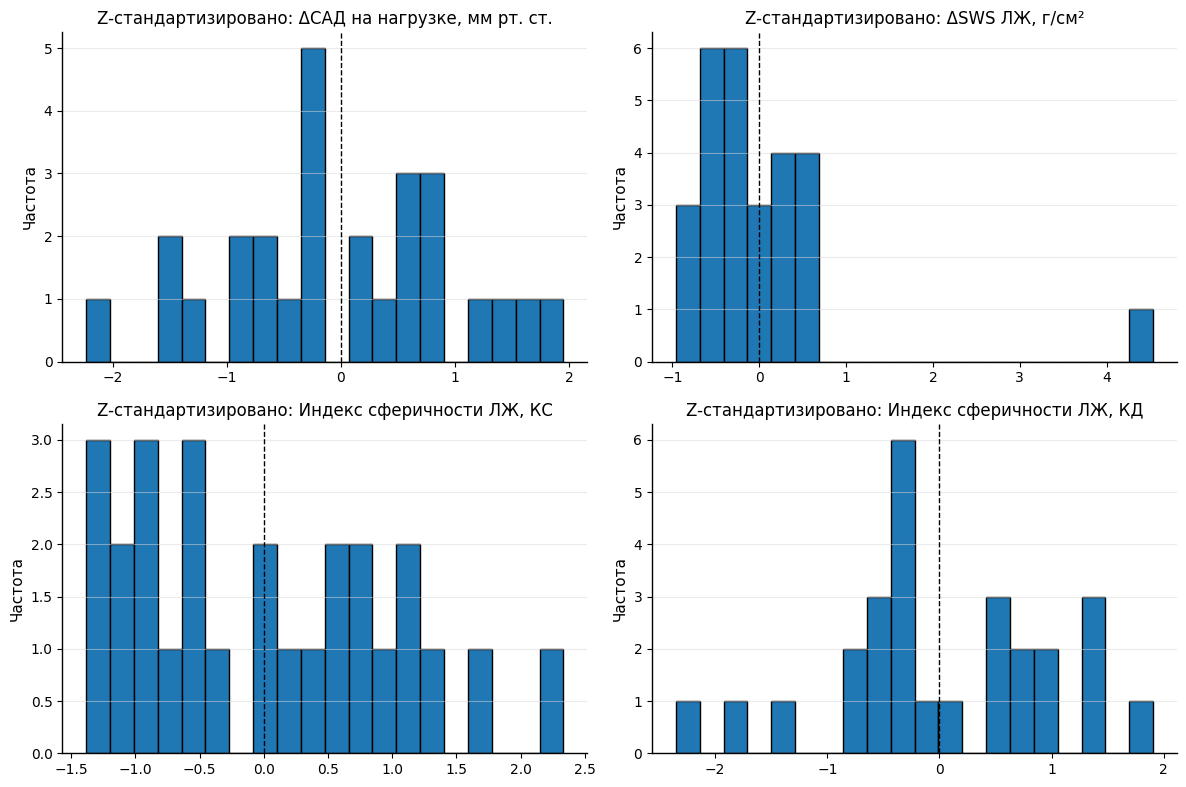

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\04_standardized_distributions.png


In [19]:
# ============================================================
# 8. Визуальный контроль стандартизированных переменных
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, X_scaled_df.columns):
    values = X_scaled_df[col].dropna()

    ax.hist(values, bins=20, edgecolor="black", linewidth=1.0)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"Z-стандартизировано: {pretty_names.get(col, col)}")
    ax.set_ylabel("Частота")
    apply_publication_style(ax)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_standardized_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", FIGURES_DIR / "04_standardized_distributions.png")

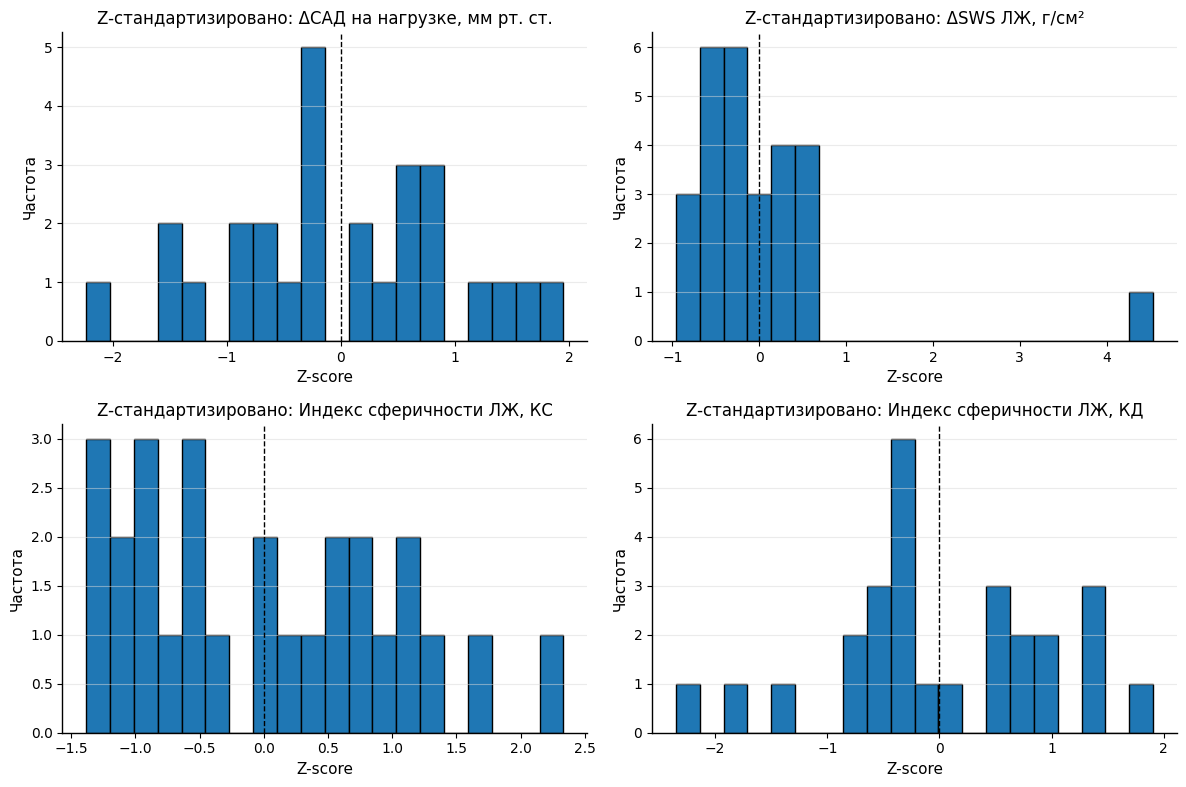

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\04_z_standardized_distributions.png


In [20]:
# ============================================================
# 8. Распределения после z-стандартизации
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, cluster_vars):
    values = X_scaled[col].dropna()

    ax.hist(values, bins=20, edgecolor="black", linewidth=1.0)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.0)

    ax.set_title(f"Z-стандартизировано: {pretty_names.get(col, col)}")
    ax.set_xlabel("Z-score")
    ax.set_ylabel("Частота")

    apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "04_z_standardized_distributions.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [21]:
# ============================================================
# 9. Подбор числа кластеров для KMeans
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

k_range = range(2, 7)

kmeans_results = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = model.fit_predict(X_scaled)

    result = {
        "algorithm": "KMeans",
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "min_cluster_size": pd.Series(labels).value_counts().min(),
        "max_cluster_size": pd.Series(labels).value_counts().max(),
    }
    
    kmeans_results.append(result)

kmeans_results_df = pd.DataFrame(kmeans_results)

display(kmeans_results_df)

kmeans_results_df.to_excel(TABLES_DIR / "kmeans_cluster_number_selection.xlsx", index=False)
print("Таблица сохранена:", TABLES_DIR / "kmeans_cluster_number_selection.xlsx")

,algorithm,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size
0,KMeans,2,77.176647,0.292192,9.984676,1.401821,11,16
1,KMeans,3,55.812195,0.325116,11.220732,1.084086,3,15
2,KMeans,4,39.707480,0.347425,13.185827,0.789973,1,14
3,KMeans,5,28.762605,0.335966,15.151815,0.719687,1,9
4,KMeans,6,22.691913,0.332504,15.789500,0.823121,1,9


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\tables\kmeans_cluster_number_selection.xlsx


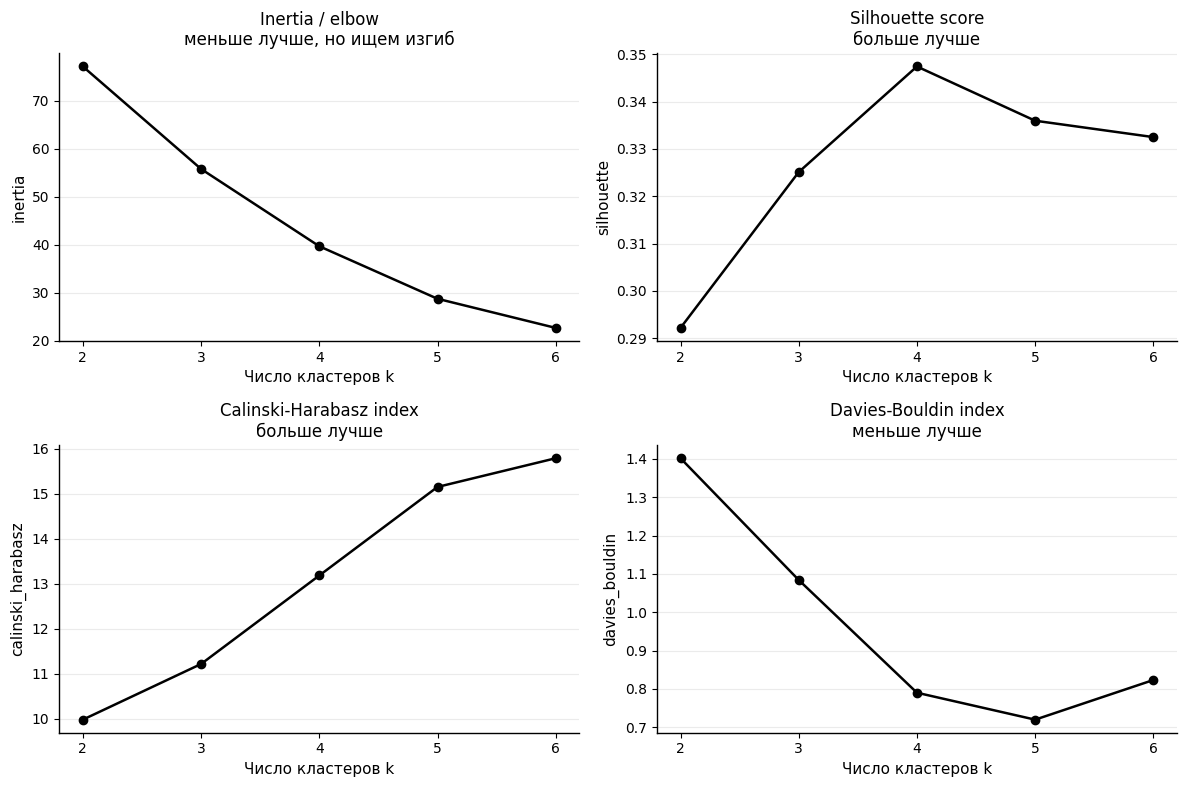

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\05_kmeans_k_selection_metrics.png


In [22]:
# ============================================================
# 10. Визуализация метрик подбора k для KMeans
# ============================================================

metrics_to_plot = [
    ("inertia", "Inertia / elbow", "меньше лучше, но ищем изгиб"),
    ("silhouette", "Silhouette score", "больше лучше"),
    ("calinski_harabasz", "Calinski-Harabasz index", "больше лучше"),
    ("davies_bouldin", "Davies-Bouldin index", "меньше лучше"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (metric, title, note) in zip(axes, metrics_to_plot):
    ax.plot(
        kmeans_results_df["k"],
        kmeans_results_df[metric],
        marker="o",
        linewidth=1.8,
        color="black"
    )

    ax.set_title(f"{title}\n{note}")
    ax.set_xlabel("Число кластеров k")
    ax.set_ylabel(metric)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "05_kmeans_k_selection_metrics.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [23]:
# ============================================================
# 11. Подбор числа кластеров для Gaussian Mixture Model
# ============================================================

from sklearn.mixture import GaussianMixture

gmm_results = []

for k in k_range:
    model = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42,
        n_init=20
    )
    
    labels = model.fit_predict(X_scaled)

    result = {
        "algorithm": "GMM",
        "k": k,
        "aic": model.aic(X_scaled),
        "bic": model.bic(X_scaled),
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "min_cluster_size": pd.Series(labels).value_counts().min(),
        "max_cluster_size": pd.Series(labels).value_counts().max(),
    }
    
    gmm_results.append(result)

gmm_results_df = pd.DataFrame(gmm_results)

display(gmm_results_df)

gmm_results_df.to_excel(TABLES_DIR / "gmm_cluster_number_selection.xlsx", index=False)
print("Таблица сохранена:", TABLES_DIR / "gmm_cluster_number_selection.xlsx")

,algorithm,k,aic,bic,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size
0,GMM,2,234.496035,272.075304,0.386554,6.776412,1.293841,3,24
1,GMM,3,194.814947,251.831769,0.308065,6.953280,0.836719,1,23
2,GMM,4,182.933537,259.387913,0.331675,12.541737,0.806288,1,12
3,GMM,5,117.103714,212.995642,0.211564,7.398884,1.057231,3,10
4,GMM,6,71.889850,187.219331,0.269999,12.482194,0.742893,1,12


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\tables\gmm_cluster_number_selection.xlsx


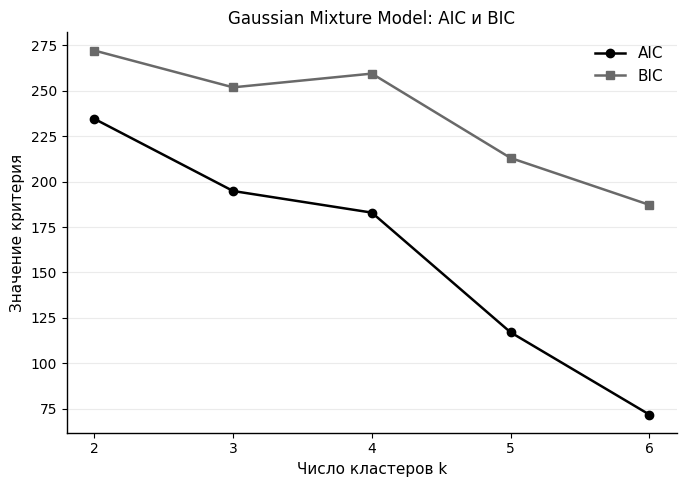

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\06_gmm_aic_bic.png


In [24]:
# ============================================================
# 12. Визуализация AIC/BIC для GMM
# ============================================================

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    gmm_results_df["k"],
    gmm_results_df["aic"],
    marker="o",
    linewidth=1.8,
    color="black",
    label="AIC"
)

ax.plot(
    gmm_results_df["k"],
    gmm_results_df["bic"],
    marker="s",
    linewidth=1.8,
    color="dimgray",
    label="BIC"
)

ax.set_title("Gaussian Mixture Model: AIC и BIC")
ax.set_xlabel("Число кластеров k")
ax.set_ylabel("Значение критерия")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(frameon=False)

apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "06_gmm_aic_bic.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [25]:
# ============================================================
# 13. Подбор числа кластеров для иерархической кластеризации
# ============================================================

from sklearn.cluster import AgglomerativeClustering

agg_results = []

for k in k_range:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )
    
    labels = model.fit_predict(X_scaled)

    result = {
        "algorithm": "Agglomerative_Ward",
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "min_cluster_size": pd.Series(labels).value_counts().min(),
        "max_cluster_size": pd.Series(labels).value_counts().max(),
    }
    
    agg_results.append(result)

agg_results_df = pd.DataFrame(agg_results)

display(agg_results_df)

agg_results_df.to_excel(TABLES_DIR / "agglomerative_cluster_number_selection.xlsx", index=False)
print("Таблица сохранена:", TABLES_DIR / "agglomerative_cluster_number_selection.xlsx")

,algorithm,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size
0,Agglomerative_Ward,2,0.294158,8.510878,1.419665,8,19
1,Agglomerative_Ward,3,0.288066,9.678209,0.874954,1,19
2,Agglomerative_Ward,4,0.329550,11.877777,0.812405,1,16
3,Agglomerative_Ward,5,0.328230,14.577536,0.763070,1,11
4,Agglomerative_Ward,6,0.342179,15.240978,0.732469,1,11


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\tables\agglomerative_cluster_number_selection.xlsx


In [26]:
# ============================================================
# 14. Сводное сравнение алгоритмов кластеризации
# ============================================================

model_selection_df = pd.concat(
    [
        kmeans_results_df[[
            "algorithm",
            "k",
            "silhouette",
            "calinski_harabasz",
            "davies_bouldin",
            "min_cluster_size",
            "max_cluster_size",
        ]],
        gmm_results_df[[
            "algorithm",
            "k",
            "silhouette",
            "calinski_harabasz",
            "davies_bouldin",
            "min_cluster_size",
            "max_cluster_size",
        ]],
        agg_results_df[[
            "algorithm",
            "k",
            "silhouette",
            "calinski_harabasz",
            "davies_bouldin",
            "min_cluster_size",
            "max_cluster_size",
        ]],
    ],
    ignore_index=True
)

model_selection_df = model_selection_df.sort_values(
    by=["silhouette", "davies_bouldin"],
    ascending=[False, True]
)

display(model_selection_df)

model_selection_df.to_excel(TABLES_DIR / "cluster_model_selection_summary.xlsx", index=False)
print("Таблица сохранена:", TABLES_DIR / "cluster_model_selection_summary.xlsx")

,algorithm,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size
5,GMM,2,0.386554,6.776412,1.293841,3,24
2,KMeans,4,0.347425,13.185827,0.789973,1,14
14,Agglomerative_Ward,6,0.342179,15.240978,0.732469,1,11
3,KMeans,5,0.335966,15.151815,0.719687,1,9
4,KMeans,6,0.332504,15.789500,0.823121,1,9
7,GMM,4,0.331675,12.541737,0.806288,1,12
12,Agglomerative_Ward,4,0.329550,11.877777,0.812405,1,16
13,Agglomerative_Ward,5,0.328230,14.577536,0.763070,1,11
1,KMeans,3,0.325116,11.220732,1.084086,3,15
6,GMM,3,0.308065,6.953280,0.836719,1,23


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\tables\cluster_model_selection_summary.xlsx


In [27]:
# ============================================================
# 15. PCA только для визуализации структуры данных
# ============================================================

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca_array = pca.fit_transform(X_scaled)

X_pca = pd.DataFrame(
    X_pca_array,
    columns=["PC1", "PC2"],
    index=X_scaled.index
)

explained = pca.explained_variance_ratio_

print(f"PC1 объясняет: {explained[0] * 100:.1f}% дисперсии")
print(f"PC2 объясняет: {explained[1] * 100:.1f}% дисперсии")
print(f"Всего PC1+PC2: {explained.sum() * 100:.1f}% дисперсии")

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=cluster_vars
)

display(loadings)

PC1 объясняет: 37.5% дисперсии
PC2 объясняет: 28.9% дисперсии
Всего PC1+PC2: 66.4% дисперсии


,PC1_loading,PC2_loading
dsws,0.538918,-0.290462
echo_lv_sws_delta_g_cm2,0.373127,-0.583822
echo_lv_sphericity_index_end_systolic_ratio,0.674206,0.184092
echo_lv_sphericity_index_end_diastolic_ratio,0.340278,0.735454


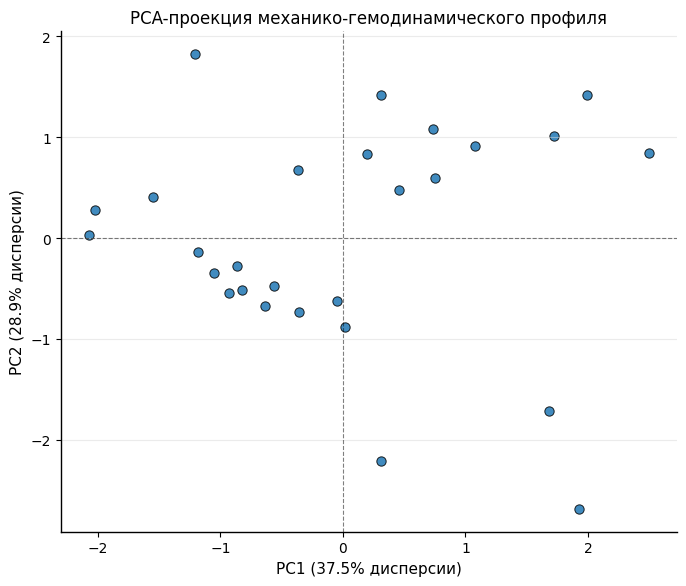

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\07_pca_projection_without_clusters.png


In [28]:
# ============================================================
# 16. PCA-проекция без кластерных меток
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    X_pca["PC1"],
    X_pca["PC2"],
    s=45,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.85
)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_title("PCA-проекция механико-гемодинамического профиля")
ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}% дисперсии)")
ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}% дисперсии)")

apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "07_pca_projection_without_clusters.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

## Интерпретация этапа подбора кластеров

Метрики кластеризации показали, что в данных присутствует некоторая внутренняя структура, однако при увеличении числа кластеров алгоритмы начинают выделять одиночные наблюдения.

Для KMeans максимальный silhouette наблюдается при k=4, однако минимальный размер кластера равен 1, что делает такую модель плохо интерпретируемой физиологически. Аналогичная проблема наблюдается для Agglomerative clustering при k ≥ 3 и для GMM при k ≥ 3.

GMM при k=2 показывает наибольший silhouette, однако формирует сильно несбалансированные группы 3 и 24 наблюдения. Это может отражать не два равнозначных фенотипа, а небольшой экстремальный подтип на фоне основной массы наблюдений.

Поэтому в качестве основной модели для интерпретации целесообразно использовать KMeans с k=2 как наиболее устойчивый и сбалансированный вариант. Дополнительно можно рассмотреть KMeans с k=3 как исследовательскую модель, а GMM с k=2 — как sensitivity analysis для выявления возможного экстремального фенотипа.

In [29]:
# ============================================================
# 17. Финальные модели-кандидаты для интерпретации
# ============================================================

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# Основная модель: наиболее устойчивый и сбалансированный вариант
kmeans_2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=50
)

labels_kmeans_2 = kmeans_2.fit_predict(X_scaled)

# Исследовательская модель: потенциально более детальная структура
kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50
)

labels_kmeans_3 = kmeans_3.fit_predict(X_scaled)

# Sensitivity-модель: возможный маленький экстремальный фенотип
gmm_2 = GaussianMixture(
    n_components=2,
    covariance_type="full",
    random_state=42,
    n_init=20
)

labels_gmm_2 = gmm_2.fit_predict(X_scaled)

# Добавляем метки в рабочую таблицу
cluster_results = cluster_df_complete.copy()

cluster_results["cluster_kmeans_2"] = labels_kmeans_2
cluster_results["cluster_kmeans_3"] = labels_kmeans_3
cluster_results["cluster_gmm_2"] = labels_gmm_2

# Добавляем PCA-координаты для визуализации
cluster_results["PC1"] = X_pca["PC1"]
cluster_results["PC2"] = X_pca["PC2"]

display(cluster_results.head())

print("Размеры кластеров KMeans k=2:")
display(cluster_results["cluster_kmeans_2"].value_counts().sort_index())

print("Размеры кластеров KMeans k=3:")
display(cluster_results["cluster_kmeans_3"].value_counts().sort_index())

print("Размеры кластеров GMM k=2:")
display(cluster_results["cluster_gmm_2"].value_counts().sort_index())

,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio,cluster_kmeans_2,cluster_kmeans_3,cluster_gmm_2,PC1,PC2
0,37.0,35.371669,0.463,0.343,1,0,0,0.306551,-2.207168
2,42.0,38.579679,0.505,0.602,0,2,1,2.497769,0.847280
3,46.0,40.536860,0.514,0.400,0,0,0,1.682081,-1.713247
4,21.0,26.281070,0.576,0.530,0,2,1,1.721520,1.010235
5,21.0,22.112423,0.365,0.462,1,1,1,-1.051052,-0.345960


Размеры кластеров KMeans k=2:


cluster_kmeans_2
0    11
1    16
Name: count, dtype: int64

Размеры кластеров KMeans k=3:


cluster_kmeans_3
0     3
1    15
2     9
Name: count, dtype: int64

Размеры кластеров GMM k=2:


cluster_gmm_2
0     3
1    24
Name: count, dtype: int64

In [30]:
# ============================================================
# 18. Профили кластеров в исходных единицах
# ============================================================

def summarize_clusters_raw(data, cluster_col, variables):
    summary = (
        data
        .groupby(cluster_col)[variables]
        .agg(["count", "mean", "std", "median", "min", "max"])
    )
    return summary


raw_profile_kmeans_2 = summarize_clusters_raw(
    cluster_results,
    "cluster_kmeans_2",
    cluster_vars
)

raw_profile_kmeans_3 = summarize_clusters_raw(
    cluster_results,
    "cluster_kmeans_3",
    cluster_vars
)

raw_profile_gmm_2 = summarize_clusters_raw(
    cluster_results,
    "cluster_gmm_2",
    cluster_vars
)

print("KMeans k=2: профили в исходных единицах")
display(raw_profile_kmeans_2)

print("KMeans k=3: профили в исходных единицах")
display(raw_profile_kmeans_3)

print("GMM k=2: профили в исходных единицах")
display(raw_profile_gmm_2)

raw_profile_kmeans_2.to_excel(TABLES_DIR / "raw_cluster_profiles_kmeans_2.xlsx")
raw_profile_kmeans_3.to_excel(TABLES_DIR / "raw_cluster_profiles_kmeans_3.xlsx")
raw_profile_gmm_2.to_excel(TABLES_DIR / "raw_cluster_profiles_gmm_2.xlsx")

KMeans k=2: профили в исходных единицах


dsws                                          echo_lv_sws_delta_g_cm2                                                         \
                 count       mean        std median   min   max                   count       mean        std     median       min         max   
cluster_kmeans_2                                                                                                                                 
0                   11  27.727273  11.279104   21.0  14.0  46.0                      11  34.624831  35.308518  23.297991  4.398595  135.312821   
1                   16  20.000000  11.667619   22.5  -3.0  37.0                      16  20.294459  11.067567  17.520053  3.042909   36.921483   

                 echo_lv_sphericity_index_end_systolic_ratio                                          echo_lv_sphericity_index_end_diastolic_ratio                              \
                                                       count      mean       std median    min    max                                        count      mean       std  median   
cluster_kmeans_2                                                                                                                                                                 
0                                                         11  0.490273  0.041076  0.480  0.438  0.576                                           11  0.529909  0.055995  0.5380   
1                                                         16  0.394437  0.040083  0.386  0.349  0.487                                           16  0.455875  0.046854  0.4635   

                                
                    min    max  
cluster_kmeans_2                
0                 0.400  0.602  
1                 0.343  0.535

KMeans k=3: профили в исходных единицах


dsws                                          echo_lv_sws_delta_g_cm2                                                          \
                 count       mean        std median   min   max                   count       mean        std     median        min         max   
cluster_kmeans_3                                                                                                                                  
0                    3  34.666667  12.662280   37.0  21.0  46.0                       3  70.407117  56.269287  40.536860  35.371669  135.312821   
1                   15  18.866667  11.128257   21.0  -3.0  33.0                      15  19.289311  10.673360  16.534148   3.042909   36.921483   
2                    9  26.444444  10.477489   21.0  14.0  42.0                       9  22.780385  11.353817  21.944419   4.398595   39.878423   

                 echo_lv_sphericity_index_end_systolic_ratio                                          echo_lv_sphericity_index_end_diastolic_ratio                             \
                                                       count      mean       std median    min    max                                        count      mean       std median   
cluster_kmeans_3                                                                                                                                                                
0                                                          3  0.483000  0.027221  0.472  0.463  0.514                                            3  0.404000  0.063095  0.400   
1                                                         15  0.389867  0.036922  0.379  0.349  0.487                                           15  0.463400  0.037167  0.465   
2                                                          9  0.489667  0.044682  0.480  0.438  0.576                                            9  0.551111  0.028989  0.547   

                                
                    min    max  
cluster_kmeans_3                
0                 0.343  0.469  
1                 0.370  0.535  
2                 0.516  0.602

GMM k=2: профили в исходных единицах


dsws                                          echo_lv_sws_delta_g_cm2                                                          \
              count       mean        std median   min   max                   count       mean        std     median        min         max   
cluster_gmm_2                                                                                                                                  
0                 3  34.666667  12.662280   37.0  21.0  46.0                       3  70.407117  56.269287  40.536860  35.371669  135.312821   
1                24  21.708333  11.296322   21.0  -3.0  42.0                      24  20.598464  10.824122  19.272427   3.042909   39.878423   

              echo_lv_sphericity_index_end_systolic_ratio                                          echo_lv_sphericity_index_end_diastolic_ratio                                    \
                                                    count      mean       std median    min    max                                        count      mean       std median    min   
cluster_gmm_2                                                                                                                                                                       
0                                                       3  0.483000  0.027221  0.472  0.463  0.514                                            3  0.404000  0.063095  0.400  0.343   
1                                                      24  0.427292  0.062930  0.408  0.349  0.576                                           24  0.496292  0.054906  0.483  0.370   

                      
                 max  
cluster_gmm_2         
0              0.469  
1              0.602

In [31]:
# ============================================================
# 19. Стандартизированные профили кластеров
# ============================================================

X_scaled_with_clusters = X_scaled.copy()
X_scaled_with_clusters["cluster_kmeans_2"] = labels_kmeans_2
X_scaled_with_clusters["cluster_kmeans_3"] = labels_kmeans_3
X_scaled_with_clusters["cluster_gmm_2"] = labels_gmm_2

z_profile_kmeans_2 = X_scaled_with_clusters.groupby("cluster_kmeans_2")[cluster_vars].mean()
z_profile_kmeans_3 = X_scaled_with_clusters.groupby("cluster_kmeans_3")[cluster_vars].mean()
z_profile_gmm_2 = X_scaled_with_clusters.groupby("cluster_gmm_2")[cluster_vars].mean()

print("KMeans k=2: средние z-score по кластерам")
display(z_profile_kmeans_2.round(2))

print("KMeans k=3: средние z-score по кластерам")
display(z_profile_kmeans_3.round(2))

print("GMM k=2: средние z-score по кластерам")
display(z_profile_gmm_2.round(2))

z_profile_kmeans_2.to_excel(TABLES_DIR / "z_cluster_profiles_kmeans_2.xlsx")
z_profile_kmeans_3.to_excel(TABLES_DIR / "z_cluster_profiles_kmeans_3.xlsx")
z_profile_gmm_2.to_excel(TABLES_DIR / "z_cluster_profiles_gmm_2.xlsx")

KMeans k=2: средние z-score по кластерам


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
cluster_kmeans_2,,,,
0,0.39,0.35,0.93,0.72
1,-0.27,-0.24,-0.64,-0.50


KMeans k=3: средние z-score по кластерам


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
cluster_kmeans_3,,,,
0,0.98,1.84,0.81,-1.35
1,-0.37,-0.28,-0.71,-0.37
2,0.28,-0.14,0.92,1.07


GMM k=2: средние z-score по кластерам


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
cluster_gmm_2,,,,
0,0.98,1.84,0.81,-1.35
1,-0.12,-0.23,-0.10,0.17


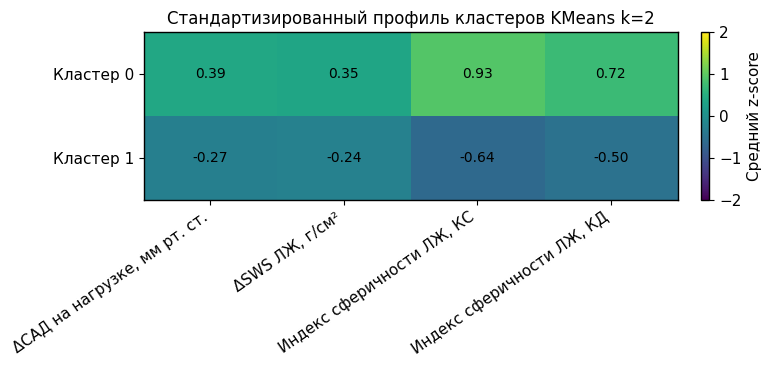

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\08_heatmap_cluster_profile_kmeans_2.png


In [32]:
# ============================================================
# 20. Heatmap профиля кластеров: KMeans k=2
# ============================================================

fig, ax = plt.subplots(figsize=(8, 3.8))

profile = z_profile_kmeans_2.copy()
profile.columns = [pretty_names.get(c, c) for c in profile.columns]

im = ax.imshow(profile.values, aspect="auto", vmin=-2, vmax=2)

ax.set_xticks(range(profile.shape[1]))
ax.set_yticks(range(profile.shape[0]))

ax.set_xticklabels(profile.columns, rotation=35, ha="right")
ax.set_yticklabels([f"Кластер {idx}" for idx in profile.index])

for i in range(profile.shape[0]):
    for j in range(profile.shape[1]):
        ax.text(
            j,
            i,
            f"{profile.values[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

ax.set_title("Стандартизированный профиль кластеров KMeans k=2")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Средний z-score")

plt.tight_layout()

fig_path = FIGURES_DIR / "08_heatmap_cluster_profile_kmeans_2.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

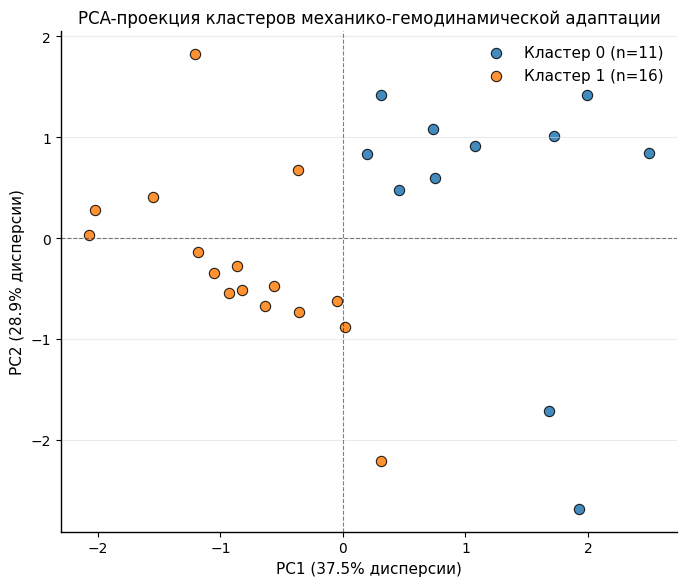

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\09_pca_clusters_kmeans_2.png


In [33]:
# ============================================================
# 21. PCA-визуализация кластеров: KMeans k=2
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

for cluster_id in sorted(cluster_results["cluster_kmeans_2"].unique()):
    subset = cluster_results[cluster_results["cluster_kmeans_2"] == cluster_id]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=55,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        label=f"Кластер {cluster_id} (n={len(subset)})"
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_title("PCA-проекция кластеров механико-гемодинамической адаптации")
ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}% дисперсии)")
ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}% дисперсии)")

ax.legend(frameon=False)

apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "09_pca_clusters_kmeans_2.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

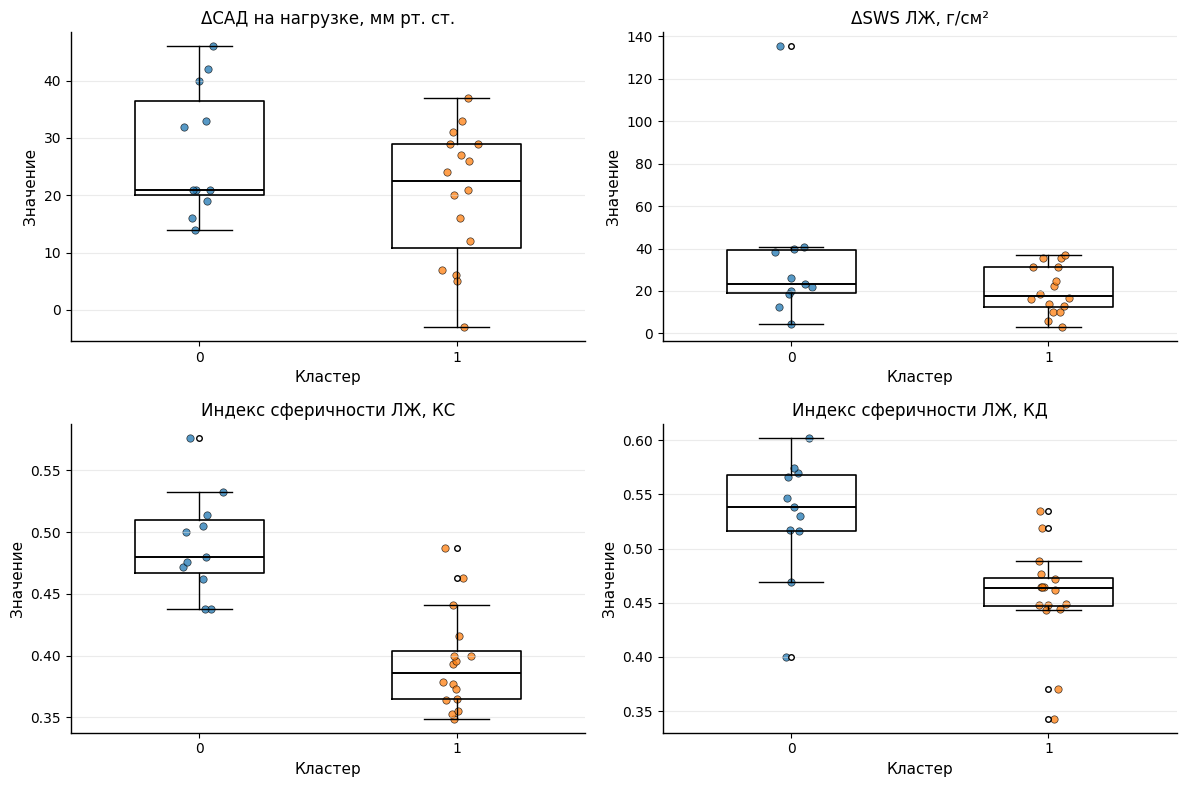

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\10_boxplots_by_cluster_kmeans_2.png


In [34]:
# ============================================================
# 22. Boxplot переменных по кластерам KMeans k=2
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

cluster_col = "cluster_kmeans_2"

for ax, col in zip(axes, cluster_vars):
    data_by_cluster = [
        cluster_results.loc[cluster_results[cluster_col] == cluster_id, col].dropna()
        for cluster_id in sorted(cluster_results[cluster_col].unique())
    ]

    ax.boxplot(
        data_by_cluster,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=4)
    )

    # Добавляем отдельные точки
    for i, values in enumerate(data_by_cluster, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=28,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.75
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_xlabel("Кластер")
    ax.set_ylabel("Значение")
    ax.set_xticklabels([f"{cluster_id}" for cluster_id in sorted(cluster_results[cluster_col].unique())])

    apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "10_boxplots_by_cluster_kmeans_2.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

## Интерпретация кластеров KMeans k=2

Кластерный анализ выделил два механико-гемодинамических фенотипа адаптации к нагрузке.

Кластер 0 характеризуется положительными z-score по всем переменным: приросту САД, приросту систолического напряжения стенки ЛЖ, индексу сферичности ЛЖ в конце систолы и индексу сферичности ЛЖ в конце диастолы. Этот кластер можно интерпретировать как фенотип повышенной нагрузочной реакции и более сферичной геометрии ЛЖ.

Кластер 1, напротив, характеризуется отрицательными z-score по всем четырём переменным. Его можно интерпретировать как фенотип умеренной нагрузочной реакции и менее сферичной геометрии ЛЖ.

Наиболее выраженное различие между кластерами наблюдается по индексам сферичности ЛЖ, особенно в конце систолы. Это позволяет предположить, что выделенные кластеры отражают не только гемодинамическую реакцию на нагрузку, но и различия в геометрическом профиле ЛЖ.

При этом в кластере 0 присутствуют отдельные экстремально высокие значения прироста SWS, поэтому перед дальнейшей интерпретацией необходимо выполнить sensitivity analysis: проверить устойчивость кластеров после исключения или робастной обработки выбросов.

In [35]:
# ============================================================
# 23. Проверка потенциальных выбросов по ΔSWS
# ============================================================

target_col = "echo_lv_sws_delta_g_cm2"

q1 = cluster_results[target_col].quantile(0.25)
q3 = cluster_results[target_col].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))

outliers_sws = cluster_results[
    (cluster_results[target_col] < lower_bound) |
    (cluster_results[target_col] > upper_bound)
].copy()

print(f"\nКоличество потенциальных выбросов по {target_col}: {len(outliers_sws)}")

display(
    outliers_sws[
        cluster_vars + ["cluster_kmeans_2", "PC1", "PC2"]
    ].sort_values(target_col, ascending=False)
)

Q1: 13.48
Q3: 33.31
IQR: 19.83
Lower bound: -16.26
Upper bound: 63.06

Количество потенциальных выбросов по echo_lv_sws_delta_g_cm2: 1


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio,cluster_kmeans_2,PC1,PC2
55,21.0,135.312821,0.472,0.469,0,1.923314,-2.684746


In [36]:
# ============================================================
# 24. Sensitivity analysis: RobustScaler + KMeans k=2
# ============================================================

from sklearn.preprocessing import RobustScaler
from sklearn.metrics import adjusted_rand_score

robust_scaler = RobustScaler()

X_robust_array = robust_scaler.fit_transform(X_raw)

X_robust = pd.DataFrame(
    X_robust_array,
    columns=cluster_vars,
    index=X_raw.index
)

kmeans_2_robust = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=50
)

labels_kmeans_2_robust = kmeans_2_robust.fit_predict(X_robust)

cluster_results["cluster_kmeans_2_robust"] = labels_kmeans_2_robust

print("Размеры кластеров после RobustScaler:")
display(cluster_results["cluster_kmeans_2_robust"].value_counts().sort_index())

ari = adjusted_rand_score(
    cluster_results["cluster_kmeans_2"],
    cluster_results["cluster_kmeans_2_robust"]
)

print(f"Adjusted Rand Index между StandardScaler и RobustScaler: {ari:.3f}")

Размеры кластеров после RobustScaler:


cluster_kmeans_2_robust
0    26
1     1
Name: count, dtype: int64

Adjusted Rand Index между StandardScaler и RobustScaler: 0.034


In [37]:
# ============================================================
# 25. Профиль робастных кластеров в исходных единицах
# ============================================================

raw_profile_kmeans_2_robust = summarize_clusters_raw(
    cluster_results,
    "cluster_kmeans_2_robust",
    cluster_vars
)

display(raw_profile_kmeans_2_robust)

raw_profile_kmeans_2_robust.to_excel(
    TABLES_DIR / "raw_cluster_profiles_kmeans_2_robust.xlsx"
)

dsws                                          echo_lv_sws_delta_g_cm2                                                             \
                        count       mean        std median   min   max                   count        mean        std      median         min         max   
cluster_kmeans_2_robust                                                                                                                                     
0                          26  23.230769  12.163249   22.5  -3.0  46.0                      26   21.933526  11.426569   20.991658    3.042909   40.536860   
1                           1  21.000000        NaN   21.0  21.0  21.0                       1  135.312821        NaN  135.312821  135.312821  135.312821   

                        echo_lv_sphericity_index_end_systolic_ratio                                       echo_lv_sphericity_index_end_diastolic_ratio                      \
                                                              count   mean       std median    min    max                                        count      mean       std   
cluster_kmeans_2_robust                                                                                                                                                      
0                                                                26  0.432  0.063024  0.427  0.349  0.576                                           26  0.486692  0.063154   
1                                                                 1  0.472       NaN  0.472  0.472  0.472                                            1  0.469000       NaN   

                                               
                         median    min    max  
cluster_kmeans_2_robust                        
0                        0.4745  0.343  0.602  
1                        0.4690  0.469  0.469

## Sensitivity analysis по выбросу ΔSWS

Проверка с использованием `RobustScaler` показала, что кластерная структура нестабильна относительно способа масштабирования признаков.

После робастного масштабирования KMeans k=2 выделил один кластер из 26 наблюдений и отдельный кластер из 1 наблюдения. Adjusted Rand Index между кластеризацией после `StandardScaler` и `RobustScaler` составил 0.034, что указывает на почти полное несовпадение разбиений.

Это означает, что исходная кластеризация чувствительна к экстремальному значению `echo_lv_sws_delta_g_cm2`.

Перед дальнейшей физиологической интерпретацией необходимо проверить, сохраняется ли структура кластеров после временного исключения наблюдения с экстремально высоким ΔSWS.

In [39]:
# ============================================================
# 26. Sensitivity analysis: исключение экстремального значения ΔSWS
# ============================================================

sws_col = "echo_lv_sws_delta_g_cm2"

# Индексы выбросов уже были найдены через IQR
outlier_indices = outliers_sws.index.tolist()

print("Индексы выбросов по ΔSWS:")
print(outlier_indices)

cluster_df_no_outlier = cluster_df_complete.drop(index=outlier_indices).copy()

print(f"\nРазмер выборки до исключения: {cluster_df_complete.shape[0]}")
print(f"Размер выборки после исключения: {cluster_df_no_outlier.shape[0]}")

display(
    cluster_df_no_outlier[cluster_vars]
    .describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
    .T
)

Индексы выбросов по ΔSWS:
[55]

Размер выборки до исключения: 27
Размер выборки после исключения: 26


,count,mean,std,min,5%,25%,50%,75%,95%,max
dsws,26.0,23.230769,12.163249,-3.000000,5.250000,16.000000,22.500000,31.750000,41.500000,46.00000
echo_lv_sws_delta_g_cm2,26.0,21.933526,11.426569,3.042909,4.797664,13.291208,20.991658,31.244649,39.553737,40.53686
echo_lv_sphericity_index_end_systolic_ratio,26.0,0.432000,0.063024,0.349000,0.353500,0.377500,0.427000,0.479000,0.527500,0.57600
echo_lv_sphericity_index_end_diastolic_ratio,26.0,0.486692,0.063154,0.343000,0.377500,0.448250,0.474500,0.533750,0.573000,0.60200


In [40]:
# ============================================================
# 27. Z-стандартизация после исключения выброса
# ============================================================

X_raw_no_outlier = cluster_df_no_outlier[cluster_vars].copy()

scaler_no_outlier = StandardScaler()
X_scaled_no_outlier_array = scaler_no_outlier.fit_transform(X_raw_no_outlier)

X_scaled_no_outlier = pd.DataFrame(
    X_scaled_no_outlier_array,
    columns=cluster_vars,
    index=X_raw_no_outlier.index
)

print("Размер матрицы после исключения выброса:", X_scaled_no_outlier.shape)

print("\nСредние после стандартизации:")
display(X_scaled_no_outlier.mean().round(6))

print("\nСтандартные отклонения после стандартизации:")
display(X_scaled_no_outlier.std(ddof=0).round(6))

Размер матрицы после исключения выброса: (26, 4)

Средние после стандартизации:


dsws                                            0.0
echo_lv_sws_delta_g_cm2                        -0.0
echo_lv_sphericity_index_end_systolic_ratio     0.0
echo_lv_sphericity_index_end_diastolic_ratio   -0.0
dtype: float64


Стандартные отклонения после стандартизации:


dsws                                            1.0
echo_lv_sws_delta_g_cm2                         1.0
echo_lv_sphericity_index_end_systolic_ratio     1.0
echo_lv_sphericity_index_end_diastolic_ratio    1.0
dtype: float64

In [41]:
# ============================================================
# 28. Повторный подбор числа кластеров KMeans без выброса ΔSWS
# ============================================================

k_range_no_outlier = range(2, 7)

kmeans_results_no_outlier = []

for k in k_range_no_outlier:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )
    
    labels = model.fit_predict(X_scaled_no_outlier)

    result = {
        "algorithm": "KMeans_no_sws_outlier",
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled_no_outlier, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled_no_outlier, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled_no_outlier, labels),
        "min_cluster_size": pd.Series(labels).value_counts().min(),
        "max_cluster_size": pd.Series(labels).value_counts().max(),
    }
    
    kmeans_results_no_outlier.append(result)

kmeans_results_no_outlier_df = pd.DataFrame(kmeans_results_no_outlier)

display(kmeans_results_no_outlier_df)

kmeans_results_no_outlier_df.to_excel(
    TABLES_DIR / "kmeans_cluster_number_selection_no_sws_outlier.xlsx",
    index=False
)

,algorithm,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size,max_cluster_size
0,KMeans_no_sws_outlier,2,74.387351,0.261037,9.554092,1.431325,10,16
1,KMeans_no_sws_outlier,3,53.333618,0.265882,10.924880,1.109066,7,10
2,KMeans_no_sws_outlier,4,42.086474,0.302640,10.788087,0.965998,2,9
3,KMeans_no_sws_outlier,5,34.169292,0.307718,10.729260,1.005586,2,9
4,KMeans_no_sws_outlier,6,28.285048,0.331739,10.707417,0.882703,2,9


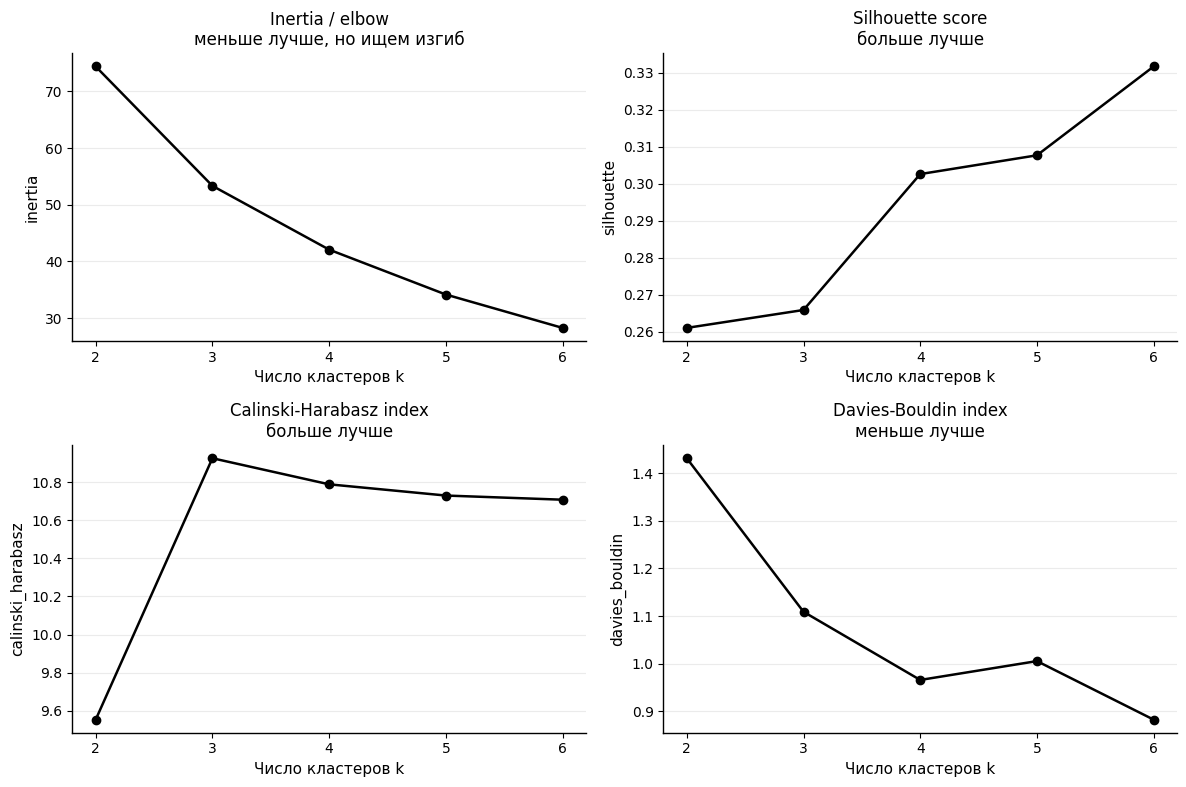

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\11_kmeans_k_selection_no_sws_outlier.png


In [42]:
# ============================================================
# 29. Визуализация подбора k без выброса ΔSWS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

metrics_to_plot = [
    ("inertia", "Inertia / elbow", "меньше лучше, но ищем изгиб"),
    ("silhouette", "Silhouette score", "больше лучше"),
    ("calinski_harabasz", "Calinski-Harabasz index", "больше лучше"),
    ("davies_bouldin", "Davies-Bouldin index", "меньше лучше"),
]

for ax, (metric, title, note) in zip(axes, metrics_to_plot):
    ax.plot(
        kmeans_results_no_outlier_df["k"],
        kmeans_results_no_outlier_df[metric],
        marker="o",
        linewidth=1.8,
        color="black"
    )

    ax.set_title(f"{title}\n{note}")
    ax.set_xlabel("Число кластеров k")
    ax.set_ylabel(metric)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "11_kmeans_k_selection_no_sws_outlier.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [43]:
# ============================================================
# 30. KMeans k=2 после исключения выброса ΔSWS
# ============================================================

kmeans_2_no_outlier = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=50
)

labels_kmeans_2_no_outlier = kmeans_2_no_outlier.fit_predict(X_scaled_no_outlier)

cluster_results_no_outlier = cluster_df_no_outlier.copy()
cluster_results_no_outlier["cluster_kmeans_2_no_sws_outlier"] = labels_kmeans_2_no_outlier

print("Размеры кластеров KMeans k=2 без выброса:")
display(
    cluster_results_no_outlier["cluster_kmeans_2_no_sws_outlier"]
    .value_counts()
    .sort_index()
)

Размеры кластеров KMeans k=2 без выброса:


cluster_kmeans_2_no_sws_outlier
0    10
1    16
Name: count, dtype: int64

In [44]:
# ============================================================
# 31. Z-профиль кластеров без выброса ΔSWS
# ============================================================

X_scaled_no_outlier_with_clusters = X_scaled_no_outlier.copy()
X_scaled_no_outlier_with_clusters["cluster_kmeans_2_no_sws_outlier"] = labels_kmeans_2_no_outlier

z_profile_kmeans_2_no_outlier = (
    X_scaled_no_outlier_with_clusters
    .groupby("cluster_kmeans_2_no_sws_outlier")[cluster_vars]
    .mean()
)

display(z_profile_kmeans_2_no_outlier.round(2))

z_profile_kmeans_2_no_outlier.to_excel(
    TABLES_DIR / "z_cluster_profiles_kmeans_2_no_sws_outlier.xlsx"
)

,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
cluster_kmeans_2_no_sws_outlier,,,,
0,0.43,0.23,0.97,0.8
1,-0.27,-0.15,-0.61,-0.5


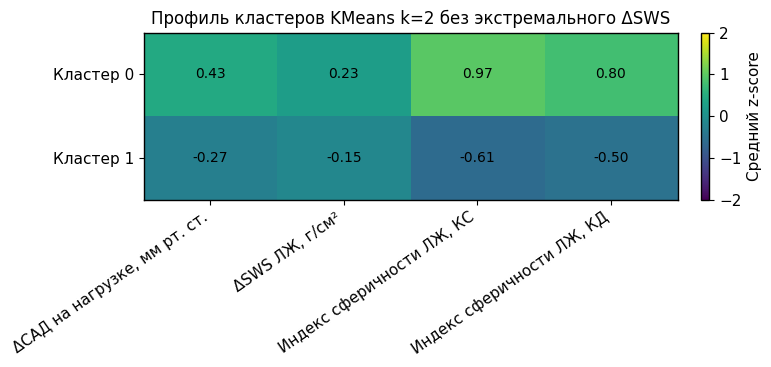

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\12_heatmap_cluster_profile_kmeans_2_no_sws_outlier.png


In [45]:
# ============================================================
# 32. Heatmap профиля кластеров без выброса ΔSWS
# ============================================================

fig, ax = plt.subplots(figsize=(8, 3.8))

profile = z_profile_kmeans_2_no_outlier.copy()
profile.columns = [pretty_names.get(c, c) for c in profile.columns]

im = ax.imshow(profile.values, aspect="auto", vmin=-2, vmax=2)

ax.set_xticks(range(profile.shape[1]))
ax.set_yticks(range(profile.shape[0]))

ax.set_xticklabels(profile.columns, rotation=35, ha="right")
ax.set_yticklabels([f"Кластер {idx}" for idx in profile.index])

for i in range(profile.shape[0]):
    for j in range(profile.shape[1]):
        ax.text(
            j,
            i,
            f"{profile.values[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

ax.set_title("Профиль кластеров KMeans k=2 без экстремального ΔSWS")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Средний z-score")

plt.tight_layout()

fig_path = FIGURES_DIR / "12_heatmap_cluster_profile_kmeans_2_no_sws_outlier.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

PC1 объясняет: 41.2% дисперсии
PC2 объясняет: 31.2% дисперсии
Всего PC1+PC2: 72.4% дисперсии


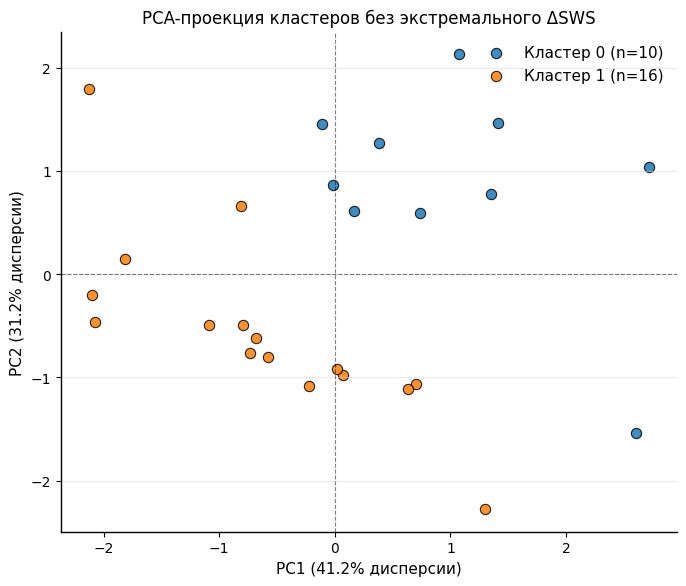

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\13_pca_clusters_kmeans_2_no_sws_outlier.png


In [46]:
# ============================================================
# 33. PCA-визуализация кластеров без выброса ΔSWS
# ============================================================

pca_no_outlier = PCA(n_components=2, random_state=42)
X_pca_no_outlier_array = pca_no_outlier.fit_transform(X_scaled_no_outlier)

X_pca_no_outlier = pd.DataFrame(
    X_pca_no_outlier_array,
    columns=["PC1", "PC2"],
    index=X_scaled_no_outlier.index
)

explained_no_outlier = pca_no_outlier.explained_variance_ratio_

cluster_results_no_outlier["PC1"] = X_pca_no_outlier["PC1"]
cluster_results_no_outlier["PC2"] = X_pca_no_outlier["PC2"]

print(f"PC1 объясняет: {explained_no_outlier[0] * 100:.1f}% дисперсии")
print(f"PC2 объясняет: {explained_no_outlier[1] * 100:.1f}% дисперсии")
print(f"Всего PC1+PC2: {explained_no_outlier.sum() * 100:.1f}% дисперсии")

fig, ax = plt.subplots(figsize=(7, 6))

cluster_col = "cluster_kmeans_2_no_sws_outlier"

for cluster_id in sorted(cluster_results_no_outlier[cluster_col].unique()):
    subset = cluster_results_no_outlier[
        cluster_results_no_outlier[cluster_col] == cluster_id
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=55,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        label=f"Кластер {cluster_id} (n={len(subset)})"
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_title("PCA-проекция кластеров без экстремального ΔSWS")
ax.set_xlabel(f"PC1 ({explained_no_outlier[0] * 100:.1f}% дисперсии)")
ax.set_ylabel(f"PC2 ({explained_no_outlier[1] * 100:.1f}% дисперсии)")

ax.legend(frameon=False)

apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "13_pca_clusters_kmeans_2_no_sws_outlier.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [47]:
# ============================================================
# 34. Сравнение кластерных меток до и после исключения выброса
# ============================================================

common_index = cluster_results_no_outlier.index.intersection(cluster_results.index)

comparison_clusters = pd.DataFrame({
    "cluster_original_kmeans_2": cluster_results.loc[common_index, "cluster_kmeans_2"],
    "cluster_no_sws_outlier_kmeans_2": cluster_results_no_outlier.loc[common_index, "cluster_kmeans_2_no_sws_outlier"],
})

display(pd.crosstab(
    comparison_clusters["cluster_original_kmeans_2"],
    comparison_clusters["cluster_no_sws_outlier_kmeans_2"],
    rownames=["Original KMeans k=2"],
    colnames=["No SWS outlier KMeans k=2"]
))

ari_no_outlier = adjusted_rand_score(
    comparison_clusters["cluster_original_kmeans_2"],
    comparison_clusters["cluster_no_sws_outlier_kmeans_2"]
)

print(f"ARI между исходной кластеризацией и кластеризацией без выброса: {ari_no_outlier:.3f}")

No SWS outlier KMeans k=2,0,1
Original KMeans k=2,,
0,10,0
1,0,16


ARI между исходной кластеризацией и кластеризацией без выброса: 1.000


## Sensitivity analysis после исключения экстремального ΔSWS

После исключения наблюдения с экстремально высоким значением `echo_lv_sws_delta_g_cm2` кластеризация KMeans k=2 была повторена на оставшихся наблюдениях.

Полученное разбиение полностью совпало с исходной кластеризацией для всех общих наблюдений: Adjusted Rand Index составил 1.000. Это означает, что один экстремальный случай влияет на масштаб распределения `ΔSWS`, но не определяет основное разделение выборки на два механико-гемодинамических фенотипа.

Таким образом, модель KMeans k=2 можно рассматривать как устойчивую для основной интерпретации. При этом пациент с экстремально высоким `ΔSWS` должен быть описан отдельно как потенциальный экстремальный механический профиль и дополнительно проверен по исходным данным.

In [48]:
# ============================================================
# 35. KMeans k=3 после исключения экстремального ΔSWS
# ============================================================

kmeans_3_no_outlier = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50
)

labels_kmeans_3_no_outlier = kmeans_3_no_outlier.fit_predict(X_scaled_no_outlier)

cluster_results_no_outlier["cluster_kmeans_3_no_sws_outlier"] = labels_kmeans_3_no_outlier

print("Размеры кластеров KMeans k=3 без экстремального ΔSWS:")
display(
    cluster_results_no_outlier["cluster_kmeans_3_no_sws_outlier"]
    .value_counts()
    .sort_index()
)

Размеры кластеров KMeans k=3 без экстремального ΔSWS:


cluster_kmeans_3_no_sws_outlier
0     9
1    10
2     7
Name: count, dtype: int64

Размеры кластеров KMeans k=3 без экстремального ΔSWS:


cluster_kmeans_3_no_sws_outlier
0     9
1    10
2     7
Name: count, dtype: int64

In [50]:
# ============================================================
# 36. Сравнение z-профилей KMeans k=2 и k=3 без выброса
# ============================================================

X_scaled_no_outlier_with_clusters = X_scaled_no_outlier.copy()

X_scaled_no_outlier_with_clusters["cluster_kmeans_2_no_sws_outlier"] = (
    cluster_results_no_outlier["cluster_kmeans_2_no_sws_outlier"]
)

X_scaled_no_outlier_with_clusters["cluster_kmeans_3_no_sws_outlier"] = (
    cluster_results_no_outlier["cluster_kmeans_3_no_sws_outlier"]
)

z_profile_kmeans_2_no_outlier = (
    X_scaled_no_outlier_with_clusters
    .groupby("cluster_kmeans_2_no_sws_outlier")[cluster_vars]
    .mean()
)

z_profile_kmeans_3_no_outlier = (
    X_scaled_no_outlier_with_clusters
    .groupby("cluster_kmeans_3_no_sws_outlier")[cluster_vars]
    .mean()
)

print("KMeans k=2 без экстремального ΔSWS:")
display(z_profile_kmeans_2_no_outlier.round(2))

print("KMeans k=3 без экстремального ΔSWS:")
display(z_profile_kmeans_3_no_outlier.round(2))

z_profile_kmeans_2_no_outlier.to_excel(
    TABLES_DIR / "z_cluster_profiles_kmeans_2_no_sws_outlier.xlsx"
)

z_profile_kmeans_3_no_outlier.to_excel(
    TABLES_DIR / "z_cluster_profiles_kmeans_3_no_sws_outlier.xlsx"
)

KMeans k=2 без экстремального ΔSWS:


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
cluster_kmeans_2_no_sws_outlier,,,,
0,0.43,0.23,0.97,0.8
1,-0.27,-0.15,-0.61,-0.5


KMeans k=3 без экстремального ΔSWS:


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
cluster_kmeans_3_no_sws_outlier,,,,
0,0.27,0.08,0.93,1.04
1,-0.66,-0.80,-0.71,-0.34
2,0.59,1.05,-0.18,-0.85


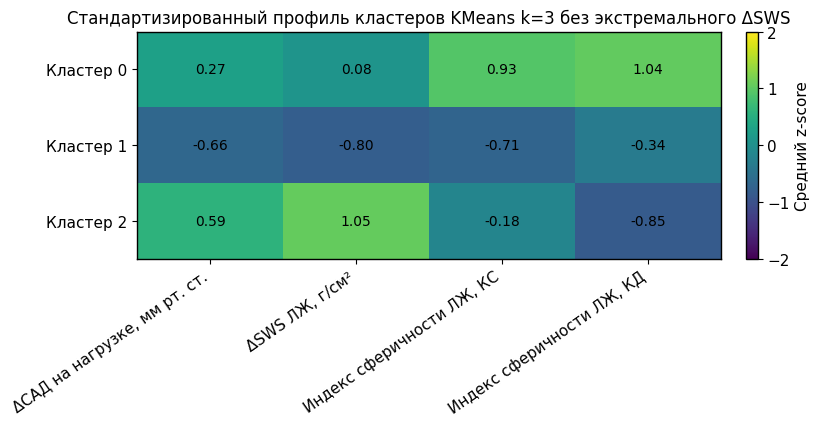

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\14_heatmap_cluster_profile_kmeans_3_no_sws_outlier.png


In [51]:
# ============================================================
# 37. Heatmap профиля кластеров KMeans k=3 без выброса
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 4.4))

profile = z_profile_kmeans_3_no_outlier.copy()
profile.columns = [pretty_names.get(c, c) for c in profile.columns]

im = ax.imshow(profile.values, aspect="auto", vmin=-2, vmax=2)

ax.set_xticks(range(profile.shape[1]))
ax.set_yticks(range(profile.shape[0]))

ax.set_xticklabels(profile.columns, rotation=35, ha="right")
ax.set_yticklabels([f"Кластер {idx}" for idx in profile.index])

for i in range(profile.shape[0]):
    for j in range(profile.shape[1]):
        ax.text(
            j,
            i,
            f"{profile.values[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=10
        )

ax.set_title("Стандартизированный профиль кластеров KMeans k=3 без экстремального ΔSWS")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Средний z-score")

plt.tight_layout()

fig_path = FIGURES_DIR / "14_heatmap_cluster_profile_kmeans_3_no_sws_outlier.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

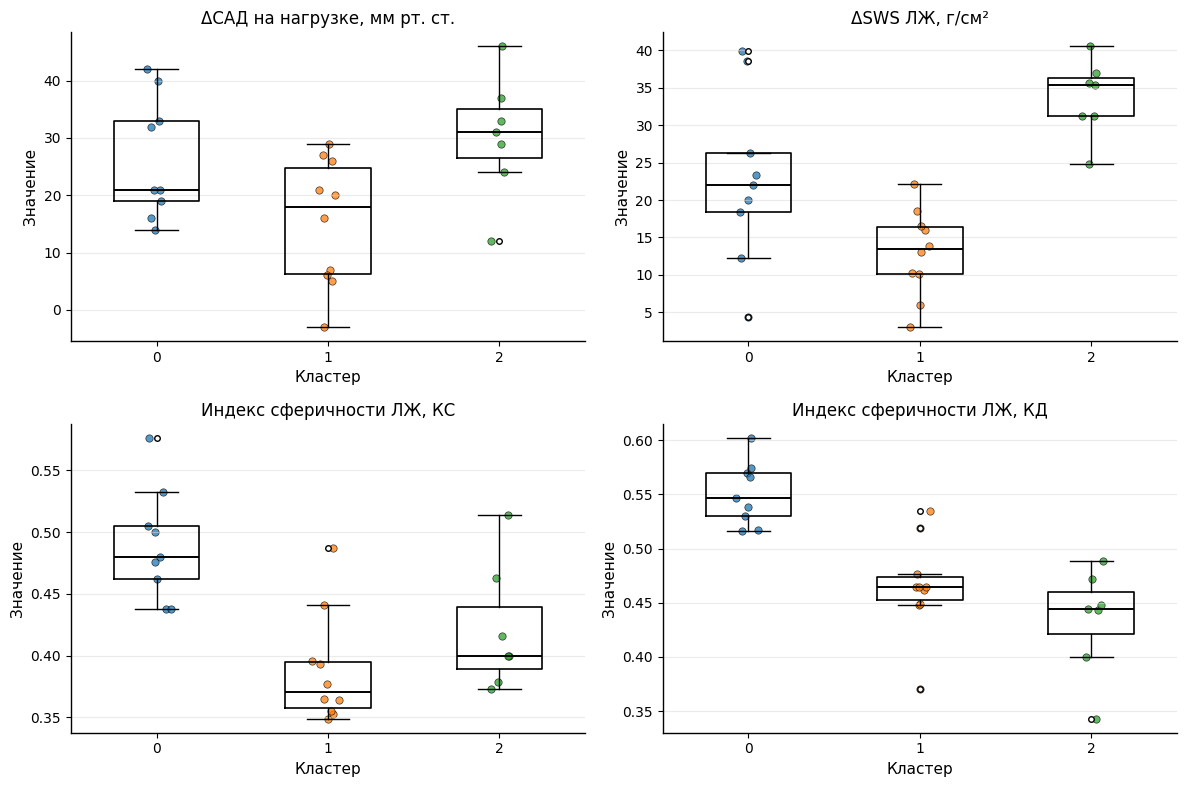

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\15_boxplots_by_cluster_kmeans_3_no_sws_outlier.png


In [52]:
# ============================================================
# 38. Boxplot переменных по кластерам KMeans k=3 без выброса
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

cluster_col = "cluster_kmeans_3_no_sws_outlier"

for ax, col in zip(axes, cluster_vars):
    cluster_ids = sorted(cluster_results_no_outlier[cluster_col].unique())

    data_by_cluster = [
        cluster_results_no_outlier.loc[
            cluster_results_no_outlier[cluster_col] == cluster_id, col
        ].dropna()
        for cluster_id in cluster_ids
    ]

    ax.boxplot(
        data_by_cluster,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4
        )
    )

    for i, values in enumerate(data_by_cluster, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=28,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.75
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_xlabel("Кластер")
    ax.set_ylabel("Значение")
    ax.set_xticklabels([str(cluster_id) for cluster_id in cluster_ids])

    apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "15_boxplots_by_cluster_kmeans_3_no_sws_outlier.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

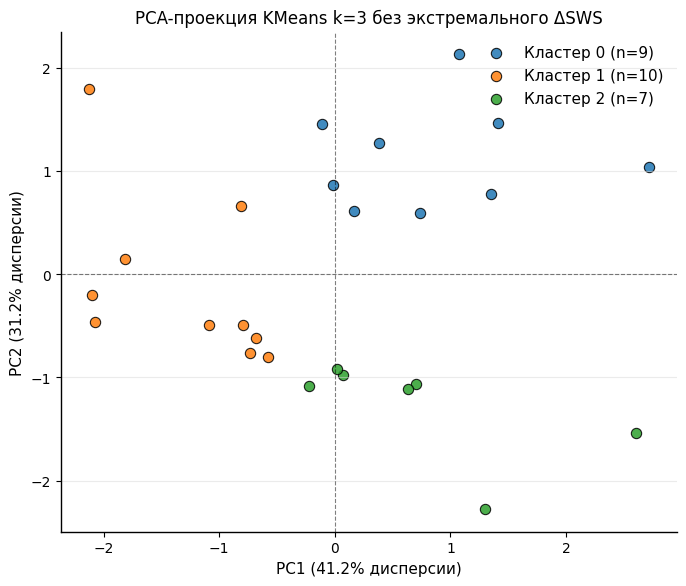

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\cluster_adaptation_to_load\figures\16_pca_clusters_kmeans_3_no_sws_outlier.png


In [53]:
# ============================================================
# 39. PCA-визуализация KMeans k=3 без выброса
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))

cluster_col = "cluster_kmeans_3_no_sws_outlier"

for cluster_id in sorted(cluster_results_no_outlier[cluster_col].unique()):
    subset = cluster_results_no_outlier[
        cluster_results_no_outlier[cluster_col] == cluster_id
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=55,
        edgecolor="black",
        linewidth=0.8,
        alpha=0.85,
        label=f"Кластер {cluster_id} (n={len(subset)})"
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_title("PCA-проекция KMeans k=3 без экстремального ΔSWS")
ax.set_xlabel(f"PC1 ({explained_no_outlier[0] * 100:.1f}% дисперсии)")
ax.set_ylabel(f"PC2 ({explained_no_outlier[1] * 100:.1f}% дисперсии)")

ax.legend(frameon=False)

apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "16_pca_clusters_kmeans_3_no_sws_outlier.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [54]:
# ============================================================
# 40. Профили кластеров k=3 в исходных единицах
# ============================================================

raw_profile_kmeans_3_no_outlier = summarize_clusters_raw(
    cluster_results_no_outlier,
    "cluster_kmeans_3_no_sws_outlier",
    cluster_vars
)

display(raw_profile_kmeans_3_no_outlier)

raw_profile_kmeans_3_no_outlier.to_excel(
    TABLES_DIR / "raw_cluster_profiles_kmeans_3_no_sws_outlier.xlsx"
)

dsws                                          echo_lv_sws_delta_g_cm2                                                         \
                                count       mean        std median   min   max                   count       mean        std     median        min        max   
cluster_kmeans_3_no_sws_outlier                                                                                                                                 
0                                   9  26.444444  10.477489   21.0  14.0  42.0                       9  22.780385  11.353817  21.944419   4.398595  39.878423   
1                                  10  15.400000  11.007068   18.0  -3.0  29.0                      10  12.952005   5.771177  13.480682   3.042909  22.112423   
2                                   7  30.285714  10.609968   31.0  12.0  46.0                       7  33.675450   5.080836  35.371669  24.801222  40.536860   

                                echo_lv_sphericity_index_end_systolic_ratio                                          echo_lv_sphericity_index_end_diastolic_ratio            \
                                                                      count      mean       std median    min    max                                        count      mean   
cluster_kmeans_3_no_sws_outlier                                                                                                                                               
0                                                                         9  0.489667  0.044682  0.480  0.438  0.576                                            9  0.551111   
1                                                                        10  0.388000  0.044422  0.371  0.349  0.487                                           10  0.465500   
2                                                                         7  0.420714  0.050642  0.400  0.373  0.514                                            7  0.434143   

                                                                
                                      std median    min    max  
cluster_kmeans_3_no_sws_outlier                                 
0                                0.028989  0.547  0.516  0.602  
1                                0.044142  0.465  0.370  0.535  
2                                0.048790  0.444  0.343  0.489

## Интерпретация KMeans k=3 без экстремального ΔSWS

После исключения наблюдения с экстремально высоким ΔSWS модель KMeans k=3 выделила три физиологически интерпретируемых фенотипа механико-гемодинамической адаптации ЛЖ.

Кластер 0 характеризуется выраженно повышенными индексами сферичности ЛЖ в систолу и диастолу при умеренном приросте САД и практически нейтральном ΔSWS. Этот профиль можно интерпретировать как геометрически-сферичный фенотип.

Кластер 1 характеризуется отрицательными z-score по всем основным переменным: приросту САД, ΔSWS и индексам сферичности. Этот кластер можно интерпретировать как низконагрузочный менее сферичный фенотип.

Кластер 2 отличается наиболее выраженным приростом САД и ΔSWS при сниженной диастолической сферичности и почти нейтральной систолической сферичности. Этот профиль можно интерпретировать как стресс-доминантный фенотип, при котором механическая нагрузка на стенку ЛЖ повышена, но это не сопровождается выраженной сферизацией ЛЖ.

Таким образом, k=3 позволяет разделить адаптацию ЛЖ не только по принципу “низкая против высокая нагрузка”, но и выделить два разных варианта повышенной механико-гемодинамической выраженности: геометрически-сферичный и стресс-доминантный.